<a href="https://colab.research.google.com/github/oegarza1/6355-data-mining-methods-assignments/blob/master/Garza_Oscar_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import os
import glob

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             precision_recall_curve, auc)

from sklearn.feature_selection import mutual_info_classif

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


1. Load Dataset


In [ ]:
# Download the Uber NYC dataset
path = kagglehub.dataset_download("fivethirtyeight/uber-pickups-in-new-york-city")

apr14_path = os.path.join(path, "uber-raw-data-apr14.csv")

df = pd.read_csv(apr14_path)


print("Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'uber-pickups-in-new-york-city' dataset.
Shape: (564516, 4)


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


This dataset consists of more than 500K customers with information on

*   Date/Time
*   Lat
*   Lon
*   Base

As part of this project, I will be focusing on Date/Time to identify High-Demand vs Low-demand hours.

2. Data preprocessing

In [ ]:
# Make sure Date/Time is datetime
df["Date/Time"] = pd.to_datetime(df["Date/Time"])

# Aggregate to hourly pickups
df_hourly = (
    df.set_index("Date/Time")
      .resample("H")
      .size()
      .reset_index(name="pickup_count")   # this is demand per hour
)

# Time features (predictors)
df_hourly["hour"] = df_hourly["Date/Time"].dt.hour
df_hourly["weekday"] = df_hourly["Date/Time"].dt.day_name()
df_hourly["is_weekend"] = df_hourly["weekday"].isin(["Saturday", "Sunday"]).astype(int)

# Lag features (past demand)
df_hourly["lag_1"] = df_hourly["pickup_count"].shift(1)
df_hourly["lag_2"] = df_hourly["pickup_count"].shift(2)

# Target: next hour’s pickups
df_hourly["pickup_count_next_hour"] = df_hourly["pickup_count"].shift(-1)

threshold = df_hourly["pickup_count"].median()

df_hourly["high_demand"] = (df_hourly["pickup_count"] >= threshold).astype(int)

# Dropping NA values for lag or next
df_model = df_hourly.dropna(subset=["lag_1", "lag_2", "pickup_count_next_hour"])

print("Shape:", df_model.shape)
df_model.head()

Shape: (717, 9)


/tmp/ipython-input-317664261.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")


,Date/Time,pickup_count,hour,weekday,is_weekend,lag_1,lag_2,pickup_count_next_hour,high_demand
2,2014-04-01 02:00:00,53,2,Tuesday,0,66.0,138.0,93.0,0
3,2014-04-01 03:00:00,93,3,Tuesday,0,53.0,66.0,166.0,0
4,2014-04-01 04:00:00,166,4,Tuesday,0,93.0,53.0,333.0,0
5,2014-04-01 05:00:00,333,5,Tuesday,0,166.0,93.0,722.0,0
6,2014-04-01 06:00:00,722,6,Tuesday,0,333.0,166.0,1001.0,1


2.1 Data Exploration

count     720.000000
mean      784.050000
std       538.648605
min        45.000000
25%       353.750000
50%       682.500000
75%      1076.500000
max      3038.000000
Name: pickup_count, dtype: float64


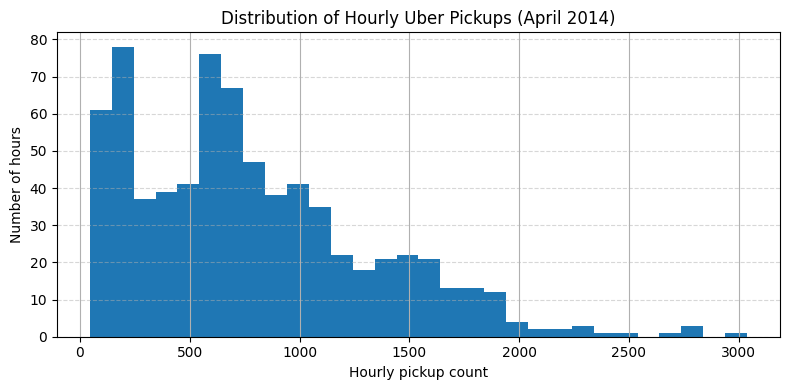

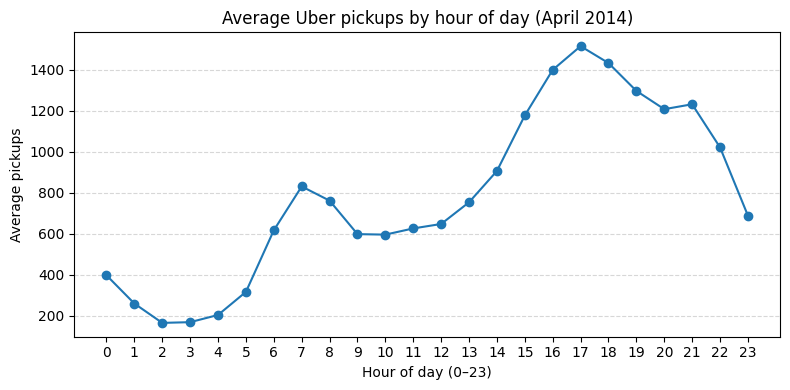

In [ ]:
# Average pickups by hour
df_hourly.groupby("hour")["pickup_count"].mean()

# Average pickups by weekday
df_hourly.groupby("weekday")["pickup_count"].mean()

# Distribution shape
print(df_hourly["pickup_count"].describe())

plt.figure(figsize=(8, 4))
df_hourly["pickup_count"].hist(bins=30)
plt.title("Distribution of Hourly Uber Pickups (April 2014)")
plt.xlabel("Hourly pickup count")
plt.ylabel("Number of hours")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Average pickups by hour (0–23)
avg_by_hour = df_hourly.groupby("hour")["pickup_count"].mean()

plt.figure(figsize=(8, 4))
plt.plot(avg_by_hour.index, avg_by_hour.values, marker="o")
plt.xlabel("Hour of day (0–23)")
plt.ylabel("Average pickups")
plt.title("Average Uber pickups by hour of day (April 2014)")
plt.xticks(range(0, 24))
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


3. Choose the target column

In [ ]:
# ===. Use  TARGET + inference helper on df_model ===

TARGET = "high_demand"

def infer_binary_target(dataframe):
    candidates, preferred = [], []
    for col in dataframe.columns:
        if col.lower() in {"id", "loan_id", "customer_id"}:
            continue
        nunq = dataframe[col].dropna().nunique()
        if nunq == 2:
            candidates.append(col)
            name = col.lower()
            if any(key in name for key in ["default", "status", "label", "target", "paid", "delinq", "chargeoff"]):
                preferred.append(col)
    if TARGET is not None:
        return TARGET
    if len(preferred) == 1:
        return preferred[0]
    if len(preferred) > 1:
        print("Multiple likely targets found (preferred):", preferred)
        return None
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        print("Multiple binary candidates found:", candidates)
        return None
    return None

if TARGET is None:
    TARGET = infer_binary_target(df_model)

if TARGET is None:
    raise ValueError("Could not infer a single binary target. Please set TARGET manually above.")

print("Chosen TARGET:", TARGET)

# Ensure 0/1 encoding
y_raw = df_model[TARGET]
if y_raw.dtype == "O" or str(y_raw.dtype).startswith("category"):
    vals = sorted(y_raw.dropna().unique().tolist())
    pos_like = [v for v in vals if str(v).lower() in ["1","yes","true","default","charged_off","not.fully.paid","bad","delinquent","late","y"]]
    if len(pos_like) == 1:
        y = (y_raw == pos_like[0]).astype(int)
    else:
        assert len(vals) == 2, "Target must be binary."
        mapping = {vals[0]:0, vals[1]:1}
        y = y_raw.map(mapping).astype(int)
        print("Target mapping used:", mapping)
else:
    uniq = sorted(pd.Series(y_raw.dropna().unique()).tolist())
    assert len(uniq) == 2, "Target must be binary."
    mapping = {uniq[0]:0, uniq[1]:1}
    y = y_raw.map(mapping).astype(int)
    if uniq != [0,1]:
        print("Target mapping used:", mapping)

# Build feature matrix X from df_model
#   - drop the classification target
#   - also drop the regression target (pickup_count_next_hour) and Date/Time to avoid leakage / weird types
X = df_model.drop(columns=[TARGET, "pickup_count_next_hour", "Date/Time"])
print("Feature shape:", X.shape)
print("Class balance (counts):\n", pd.Series(y).value_counts().rename({0:"negative",1:"positive"}))
print("Class balance (proportions):\n", pd.Series(y).value_counts(normalize=True).round(3).rename({0:"negative",1:"positive"}))


Chosen TARGET: high_demand
Feature shape: (717, 6)
Class balance (counts):
 high_demand
positive    359
negative    358
Name: count, dtype: int64
Class balance (proportions):
 high_demand
positive    0.501
negative    0.499
Name: proportion, dtype: float64


The notebook encoded the target so that positive = 1 = high demand and negative = 0 = low demand. There are 358 negatives and 359 positives.

4. Train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (537, 6)  Test size: (180, 6)


5. Preprocessing

In [ ]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

6. Logistic Regression Classifer


In [ ]:
pipe = Pipeline(steps=[("preprocess", preprocessor),
                      ("logreg", LogisticRegression(max_iter=1000, solver="lbfgs"))])
pipe.fit(X_train, y_train)
print("Logistic Regression pipeline trained.")

Logistic Regression pipeline trained.


LR Accuracy: 0.978
LR Precision: 0.989
LR Recall: 0.967
LR F1 score: 0.978
LR ROC AUC: 0.999


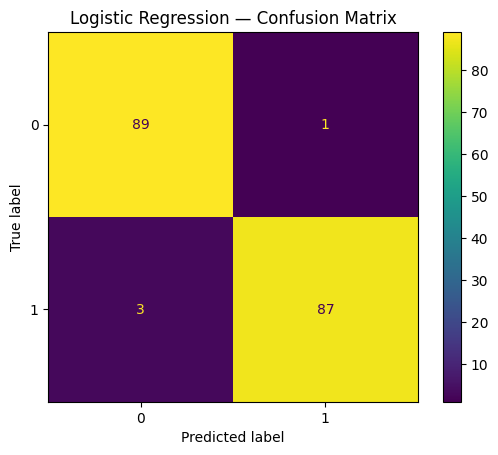

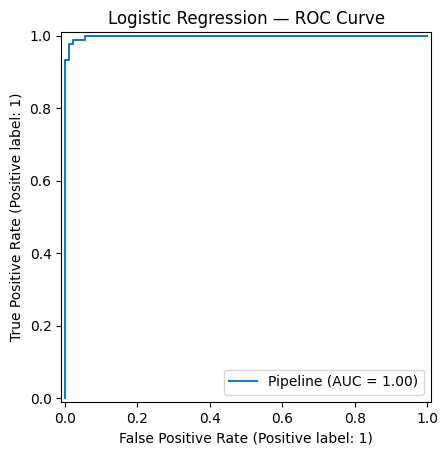

In [ ]:
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
roc = roc_auc_score(y_test, y_prob)

print(f"LR Accuracy: {acc:.3f}")
print(f"LR Precision: {prec:.3f}")
print(f"LR Recall: {rec:.3f}")
print(f"LR F1 score: {f1:.3f}")
print(f"LR ROC AUC: {roc:.3f}")

ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(pipe, X_test, y_test)
plt.title("Logistic Regression — ROC Curve")
plt.show()

**Performance metrics**

Accuracy 0.978, precision 0.989, recall 0.967, F1 0.978, ROC AUC 0.999.

Confusion matrix counts: TN 89, FP 1, FN 3, TP 87.

The model detects high-demand hours with very high sensitivity. It correctly identifies 87 out of 90 actual high-demand hours, which is recall 0.967, so it only misses about 3 percent of positives. When it predicts high demand, 87 of 88 predicted positives are truly high-demand hours, which is precision 0.989, meaning just 1 false alarm. In short, the classifier achieves both excellent precision and excellent recall, making very few mistakes in either direction.

**ROC curve**

The ROC curve plots true positive rate against false positive rate across decision thresholds. The area under the curve is 0.999.

An AUC this close to 1.0 means the model almost perfectly ranks a random high-demand hour above a random low-demand hour. This indicates extremely strong separation between the two classes. By adjusting the decision threshold, you can fine-tune the balance between catching every high-demand hour and minimizing false alarms.

**Takeaway**

The logistic regression model performs exceptionally well overall. It achieves very high precision and recall, with only a handful of misclassified hours, and the near-perfect ROC AUC confirms that the underlying probability estimates separate the classes extremely clearly. Depending on the project goals, you could still explore threshold tuning or regularization checks, but as it stands, the classifier provides highly reliable identification of high-demand periods.

Cross-validation for Logistic Regression

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
roc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print(f"LR CV accuracy mean ± std: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"LR CV ROC AUC mean ± std: {roc_scores.mean():.3f} ± {roc_scores.std():.3f}")

LR CV accuracy mean ± std: 0.975 ± 0.009
LR CV ROC AUC mean ± std: 0.998 ± 0.002


Mean accuracy 0.975 ± 0.009 and mean ROC AUC 0.998 ± 0.002.

These are extremely close to the held-out test results (accuracy 0.978, AUC 0.999), which suggests essentially no overfitting. The very small standard deviations indicate that performance is highly stable across folds, reinforcing that the Logistic Regression model generalizes reliably to unseen data.

Interpretation for Logistic Regression

Logistic Regression: accuracy 0.978, precision 0.989, recall 0.967, F1 0.978, AUC 0.999.

**Interpretation**

The logistic regression model performs extremely well on this dataset. It correctly classifies the vast majority of observations and achieves both very high precision and very high recall, meaning it catches almost all positive cases (high-demand hours) while making very few false alarms. The near-perfect ROC AUC of 0.999 indicates that the model almost perfectly ranks positive examples above negative ones. Combined with the cross-validation results (mean accuracy 0.975 ± 0.009 and mean AUC 0.998 ± 0.002), this suggests that the classifier generalizes reliably and is a strong candidate for deployment when the goal is to accurately identify high-demand periods with minimal misclassification.

7. Threshold tuning for Logistic Regression



Best validation F1 threshold: 0.471
Best F1: 0.981, precision: 0.981, recall: 0.981
Accuracy: 0.972
Precision: 0.978
Recall: 0.967
F1 score: 0.972
ROC AUC (unchanged by threshold): 0.998


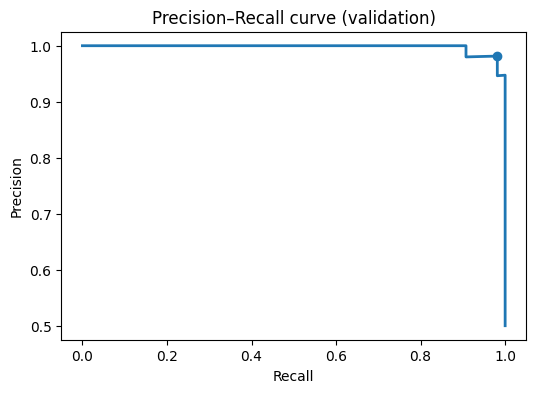

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)

pipe.fit(X_tr, y_tr)
val_prob = pipe.predict_proba(X_val)[:, 1]
prec_curve, rec_curve, thresh = precision_recall_curve(y_val, val_prob)
f1s = 2 * (prec_curve * rec_curve) / (prec_curve + rec_curve + 1e-12)
best_idx = np.nanargmax(f1s)
best_thresh = thresh[best_idx]

print(f"Best validation F1 threshold: {best_thresh:.3f}")
print(f"Best F1: {f1s[best_idx]:.3f}, precision: {prec_curve[best_idx]:.3f}, recall: {rec_curve[best_idx]:.3f}")

test_prob = pipe.predict_proba(X_test)[:, 1]
test_pred_best = (test_prob >= best_thresh).astype(int)

acc_b = accuracy_score(y_test, test_pred_best)
prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(y_test, test_pred_best, average="binary", zero_division=0)
roc_b = roc_auc_score(y_test, test_prob)

print(f"Accuracy: {acc_b:.3f}")
print(f"Precision: {prec_b:.3f}")
print(f"Recall: {rec_b:.3f}")
print(f"F1 score: {f1_b:.3f}")
print(f"ROC AUC (unchanged by threshold): {roc_b:.3f}")

plt.figure(figsize=(6,4))
plt.plot(rec_curve, prec_curve, lw=2)
plt.scatter(rec_curve[best_idx], prec_curve[best_idx])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve (validation)")
plt.show()

Best validation threshold is 0.471.

At that point on the validation PR curve, F1 = 0.981 with precision 0.981 and recall 0.981.
Applying this threshold to the test set gives accuracy 0.972, precision 0.978, recall 0.967, F1 0.972, and ROC AUC 0.998 (AUC does not change with threshold).

Compared to the default 0.50 threshold used earlier (accuracy 0.978, precision 0.989, recall 0.967, F1 0.978, AUC 0.999), this tuned threshold produces very similar performance. Precision drops slightly while recall stays essentially the same, and F1 and accuracy are only marginally lower. In other words, the model is already operating in a near-perfect region of the PR curve, so threshold tuning does not materially change performance—any reasonable threshold in this range will catch almost all high-demand hours while keeping false alarms extremely rare.

**Precision–Recall curve (validation)**

The precision–recall curve is almost flat near the top, with precision remaining close to 1.0 across a wide range of recall values. The dot marks the threshold that maximizes F1 on the validation split (around 0.47 here). Because the model separates the classes so well, precision only begins to drop at the extreme high-recall end, indicating that you can achieve both very high recall and very high precision simultaneously. The chosen threshold lies on this plateau, reflecting a balanced operating point where the model maintains excellent precision while still recovering nearly all positive (high-demand) hours.

**Assignment Resources:** Used past assignments as a template, and followed  for majority of code with edits to match assignment instructions. I used ChatGPT and Gemini for questions, output review, and ideas.  All analysis is my own.

> Add blockquote

